In [14]:
# https://www.kaggle.com/datasets/rasvob/uci-poker-hand-dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rasvob/uci-poker-hand-dataset")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\000010478\.cache\kagglehub\datasets\rasvob\uci-poker-hand-dataset\versions\1


In [15]:
import pandas as pd
data=pd.read_csv(path + "/poker-hand-training-true.data", header=None)
x=data.iloc[:, :-1].values
y=data.iloc[:, -1].values
print(x.shape, y.shape  )

(25010, 10) (25010,)


In [16]:
import torch
dataset=[(xi,yi) for xi,yi in zip(x,y)]
from torch.utils.data import DataLoader
loader=DataLoader(dataset, batch_size=1024, shuffle=True)
xi,yi=next(iter(loader))
xi.shape, yi.shape

(torch.Size([1024, 10]), torch.Size([1024]))

In [17]:
modelo=torch.nn.Sequential(
    torch.nn.Linear(10, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 10)
)
yest=modelo(xi.float())
xi.shape, yi.shape, yest.shape

(torch.Size([1024, 10]), torch.Size([1024]), torch.Size([1024, 10]))

In [18]:
ferror=torch.nn.CrossEntropyLoss()
optim=torch.optim.Adam(modelo.parameters(), lr=0.001)

Epoch 0, Loss: 1.4603623843193054
Epoch 10, Loss: 0.9518695735931396
Epoch 20, Loss: 0.9278011012077332
Epoch 30, Loss: 0.9115351057052612
Epoch 40, Loss: 0.8962471842765808
Epoch 50, Loss: 0.8727648305892944
Epoch 60, Loss: 0.8525252294540405
Epoch 70, Loss: 0.8180928707122803
Epoch 80, Loss: 0.7898069286346435
Epoch 90, Loss: 0.7612260794639587
Epoch 100, Loss: 0.7410049939155579
Epoch 110, Loss: 0.7121018576622009
Epoch 120, Loss: 0.6882287001609803
Epoch 130, Loss: 0.6631544423103333
Epoch 140, Loss: 0.6466362309455872
Epoch 150, Loss: 0.6186451601982117
Epoch 160, Loss: 0.5977869343757629
Epoch 170, Loss: 0.5725515699386596
Epoch 180, Loss: 0.5489708876609802
Epoch 190, Loss: 0.5318743181228638
Epoch 200, Loss: 0.5146319103240967
Epoch 210, Loss: 0.5006578755378723
Epoch 220, Loss: 0.4790370583534241
Epoch 230, Loss: 0.4529102051258087
Epoch 240, Loss: 0.42979751944541933
Epoch 250, Loss: 0.4114198338985443
Epoch 260, Loss: 0.3859007525444031
Epoch 270, Loss: 0.37430580615997316
E

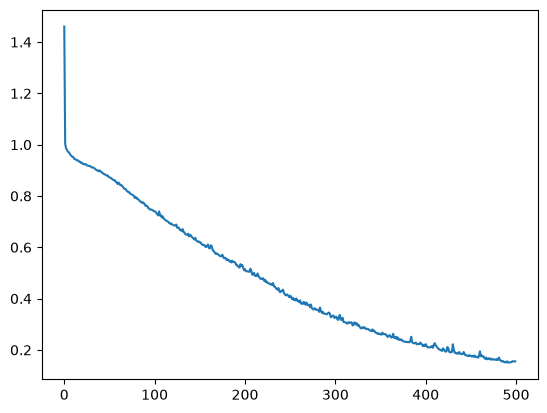

In [19]:
import numpy as np
epochs=500
error=[]
for epoch in range(epochs):
    tmp=[]
    for xi,yi in loader:
        optim.zero_grad()
        yest=modelo(xi.float())
        loss=ferror(yest, yi.long())
        loss.backward()
        optim.step()
        tmp.append(loss.item())
    error.append(np.mean(tmp))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {error[-1]}")

import matplotlib.pyplot as plt
plt.plot(error)